##### Task 8: Coding Task — Iris Dataset (3 classes): 
    a) Train SVC with kernel='rbf'. Use GridSearchCV to find best C and gamma. 
    b) Train KNN. Find optimal k (1–20). Plot k vs accuracy curve. 
    c) Compare SVM, KNN, and Logistic Regression using 5-fold cross-validation. 
    d) Try KNN with metric='manhattan' vs metric='euclidean'. Which performs better? 
  

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

##### A

In [12]:
# Parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# SVM model
svc = SVC(kernel='rbf')

# GridSearchCV
grid = GridSearchCV( svc, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Best model
best_svm = grid.best_estimator_

# Predictions
y_pred = best_svm.predict(X_test)

# Accuracy
svm_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", svm_acc)

SVC(C=1, gamma=0.1)
Best Parameters: {'C': 1, 'gamma': 0.1}
Best CV Score: 0.9833333333333334
Test Accuracy: 0.9333333333333333


Best k: 3
Best Accuracy: 1.0


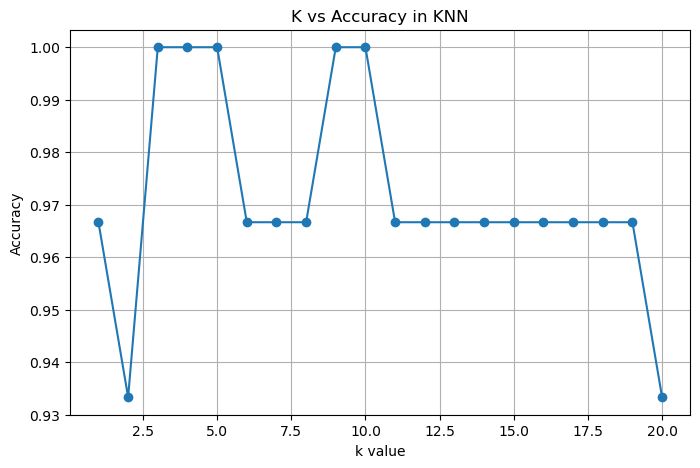

In [9]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Best k
best_k = k_values[np.argmax(accuracies)]

print("Best k:", best_k)
print("Best Accuracy:", max(accuracies))

plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy in KNN")

plt.grid(True)
plt.show()

In [10]:
models = {
    'SVM': best_svm,
    'KNN': KNeighborsClassifier(n_neighbors=best_k),
    'Logistic Regression': LogisticRegression(max_iter=200)
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    print(f"\n{name}")
    print("CV Scores:", scores)
    print("Mean Accuracy:", scores.mean())


SVM
CV Scores: [0.96666667 1.         0.96666667 0.96666667 1.        ]
Mean Accuracy: 0.9800000000000001

KNN
CV Scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean Accuracy: 0.9666666666666668

Logistic Regression
CV Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean Accuracy: 0.9733333333333334


In [11]:
# Euclidean
knn_euclidean = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean'
)

knn_euclidean.fit(X_train, y_train)

pred_e = knn_euclidean.predict(X_test)

acc_e = accuracy_score(y_test, pred_e)

# Manhattan
knn_manhattan = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

knn_manhattan.fit(X_train, y_train)

pred_m = knn_manhattan.predict(X_test)

acc_m = accuracy_score(y_test, pred_m)

print("Euclidean Accuracy:", acc_e)
print("Manhattan Accuracy:", acc_m)

Euclidean Accuracy: 1.0
Manhattan Accuracy: 1.0


##### Task 9: Experiment: Curse of Dimensionality Demo: 
    a) How much did accuracy drop? 
    b) Apply PCA(n_components=2) to X_noisy and retrain. Does accuracy recover? 
    c) What does this demonstrate about KNN in high dimensions?

In [ ]:
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

X, y = make_classification( n_samples=500, n_features=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred = knn.predict(X_test)

original_acc = accuracy_score(y_test, pred)

print("Original Accuracy:", original_acc)


X_noisy = np.hstack([X,np.random.randn(500, 50)])

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy,y,test_size=0.2,random_state=42)

knn_noise = KNeighborsClassifier(n_neighbors=5)

knn_noise.fit(X_train_n, y_train_n)

pred_noise = knn_noise.predict(X_test_n)

noise_acc = accuracy_score(y_test_n, pred_noise)

print("Accuracy with Noise Features:", noise_acc)

drop = original_acc - noise_acc

print("Accuracy Drop:", drop)

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_noisy)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

knn_pca = KNeighborsClassifier(n_neighbors=5)

knn_pca.fit(X_train_p, y_train_p)

pred_pca = knn_pca.predict(X_test_p)

pca_acc = accuracy_score(y_test_p, pred_pca)

print("Accuracy after PCA:", pca_acc)